# CS-gr Images

- made cs-gr continuum subtracted images and tweaked the continuum subtraction
- now need to compare the results for the CS-gr images with the same measurements from the CS-ZP images.
- all CS-gr columns should have `CSGR_` prefix, and column names are otherwise the same. 

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.table import Table

from hapy.utils.results_table import prepare_analysis_table
from hapy.utils import plotting

import warnings
warnings.filterwarnings("ignore")

mycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
%run ~/github/Virgo/programs/readtablesv2.py
ssfr = v.cigale['bayes.sfh.sfr'] / v.cigale['bayes.stellar.m_star']

logsfr = np.log10(v.cigale['bayes.sfh.sfr'])
logmstar = np.log10(v.cigale['bayes.stellar.m_star'])
logssfr = logsfr - logmstar


table directory =  /Users/rfinn/research/Virgo/tables-north/v2/


In [3]:
infile = '/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260514/merged_results_virgo_20260514.fits'
#cinfile = '/Users/rfinn/research/Virgo/koopmann-images/hapy_results/cluster/hapy-output-20260430/merged_results_archive_20260430.fits'
%run ~/github/hapy/scripts/science_morphology.py $infile --scheme virgo 


Read 782 rows from /Users/rfinn/research/Virgo/hatools_test/hapy-output-20260514/merged_results_virgo_20260514.fits
UPDATE: adding VFINDEX
REVIEW_PRIORITY SUMMARY
{'high': 65, 'low': 283, 'medium': 434}
ELL_MISMATCH 235
FILTER_WARNING 75
WARN_MASK 11
BRIGHT_STAR_FLAG 0
WARN_WEAK_HA 281


In [7]:
tab.colnames

['VFID',
 'GALNAME',
 'OBJID',
 'RA',
 'DEC',
 'REDSHIFT',
 'VR',
 'HAPY_VERSION',
 'RUN_DATE',
 'TELESCOPE',
 'DATEOBS',
 'POINTING',
 'SCHEME',
 'PARENT_RIMAGE',
 'PARENT_HIMAGE',
 'HFILTER',
 'PIXSCALE',
 'TAG',
 'CUTDIR',
 'MASK_FITS',
 'MASK_SOURCE',
 'PSF_FITS',
 'R_FITS',
 'CS_FITS',
 'RFILTER_FILENAME',
 'RFILTER_CENTER',
 'RFILTER_WIDTH',
 'HFILTER_FILENAME',
 'HFILTER_CENTER',
 'HFILTER_WIDTH',
 'PSF_SOURCE',
 'STAGE',
 'STATUS',
 'MASK_SEC',
 'PHOT_SEC',
 'CSGR_SEC',
 'SM_SEC',
 'GAL_NC_SEC',
 'GAL_CV_SEC',
 'TOTAL_SEC',
 'PSF_OK',
 'MASK_OK',
 'PHOT_OK',
 'HAPY_MORPH_OK',
 'R_PROFILE_OK',
 'H_PROFILE_OK',
 'R_SM_OK',
 'H_SM_OK',
 'GAL_NC_OK',
 'GAL_CV_OK',
 'GAL_CV_INIT_FROM_NC',
 'GAL_NC_RERUN_FIXEDN',
 'GAL_CV_RERUN_FIXEDN',
 'ELL_MISMATCH',
 'R_PETRO_OK',
 'R_EXPFIT_OK',
 'R_LOGFIT_OK',
 'H_PETRO_OK',
 'H_EXPFIT_OK',
 'H_LOGFIT_OK',
 'BRIGHT_STAR_FLAG',
 'BRIGHT_STAR_DIST_ARCSEC',
 'BRIGHT_STAR_MASKRAD_ARCSEC',
 'BRIGHT_STAR_MAG',
 'ELL0_MASKFRAC',
 'ELL0_MASK_WARN',
 'E

Text(0.5, 1.0, 'CS Scale by Telescope')

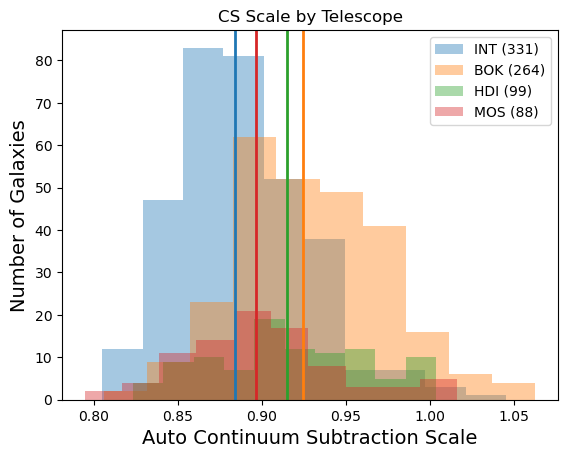

In [27]:
# plot contscl as a function of telescopes

tels = ['INT','BOK', 'HDI','MOS',]

plt.figure()
for i,tel in enumerate(tels):
    flag = tab['TELESCOPE'] == tel
    x = tab['CSGR_CONTSCL'][flag]
    l = f"{tel} ({np.sum(flag)})"
    plt.hist(x, label=l, alpha=.4, color=mycolors[i])
    plt.axvline(np.median(x), color=mycolors[i],lw=2)
plt.legend()

plt.xlabel("Auto Continuum Subtraction Scale",fontsize=14)
plt.ylabel("Number of Galaxies",fontsize=14)
plt.title("CS Scale by Telescope")

Text(0, 0.5, 'CSGR_SKYSTD_ADU')

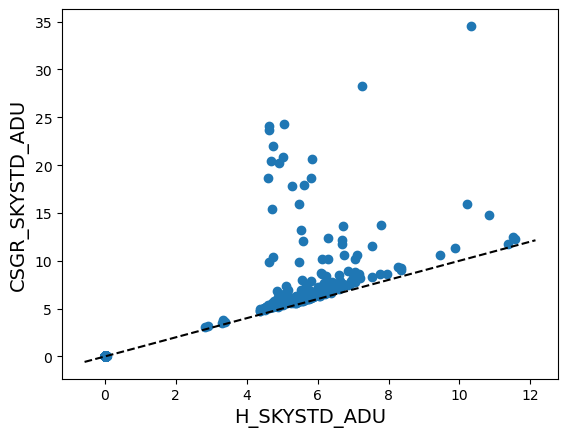

In [34]:
c1 = 'H_SKYSTD_ADU'
c2 = 'CSGR_SKYSTD_ADU'


plt.figure()
plt.scatter(tab[c1],tab[c2])
x1,x2 = plt.xlim()
xline=np.linspace(x1,x2,100)
plt.plot(xline,xline,'k--')

plt.xlabel(c1,fontsize=14)
plt.ylabel(c2,fontsize=14)